# ==========================================================
# NOTEBOOK 2 and 3
# Federated Learning using FedAvg
# University Anxiety Prediction

In [1]:
# ==========================================================
# NOTEBOOK 2
# Federated Learning using FedAvg
# University Anxiety Prediction
# ==========================================================

# ==========================================================
# 1. Import Libraries
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

import tensorflow as tf

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


# ==========================================================
# 2. Load Cleaned Dataset
# ==========================================================

In [2]:
# ==========================================================
# 2. Load Cleaned Dataset
# ==========================================================

df = pd.read_csv("/kaggle/input/datasets/digrok/anxiety-23/Anxiety.csv")

print(df.shape)

df.head()

(2028, 16)


,Age,Gender,University,Department,Academic Year,Current CGPA,Did you receive a waiver or scholarship at your university?,"1. In a semester, how often you felt nervous, anxious or on edge due to academic pressure?","2. In a semester, how often have you been unable to stop worrying about your academic affairs?","3. In a semester, how often have you had trouble relaxing due to academic pressure?","4. In a semester, how often have you been easily annoyed or irritated because of academic pressure?","5. In a semester, how often have you worried too much about academic affairs?","6. In a semester, how often have you been so restless due to academic pressure that it is hard to sit still?","7. In a semester, how often have you felt afraid, as if something awful might happen?",Anxiety Value,Anxiety Label
0,18-22,Female,"Independent University, Bangladesh (IUB)",Engineering - CS / CSE / CSC / Similar to CS,Second Year or Equivalent,2.50 - 2.99,No,2,2,3,2,2,2,2,15,Severe Anxiety
1,18-22,Male,"Independent University, Bangladesh (IUB)",Engineering - CS / CSE / CSC / Similar to CS,Third Year or Equivalent,3.00 - 3.39,No,1,2,2,1,1,3,2,12,Moderate Anxiety
2,18-22,Male,American International University Bangladesh (...,Engineering - CS / CSE / CSC / Similar to CS,Third Year or Equivalent,3.00 - 3.39,No,0,0,0,0,0,0,0,0,Minimal Anxiety
3,18-22,Male,American International University Bangladesh (...,Engineering - CS / CSE / CSC / Similar to CS,Third Year or Equivalent,3.00 - 3.39,No,2,1,1,1,2,1,2,10,Moderate Anxiety
4,18-22,Male,North South University (NSU),Engineering - CS / CSE / CSC / Similar to CS,Second Year or Equivalent,2.50 - 2.99,No,3,0,3,3,1,1,3,14,Moderate Anxiety


In [3]:
# ==========================================================
# Encode All Categorical Columns
# ==========================================================

from sklearn.preprocessing import LabelEncoder

# Make a copy
df = df.copy()

# Store encoders (optional, useful later)
label_encoders = {}

# Find all object columns
categorical_columns = df.select_dtypes(include=['object']).columns

print("Categorical Columns:")
print(categorical_columns)

# Encode each categorical column
for col in categorical_columns:

    le = LabelEncoder()

    df[col] = le.fit_transform(df[col].astype(str))

    label_encoders[col] = le

print("\nEncoding Completed Successfully!")

df.head()

Categorical Columns:
Index(['Age', 'Gender', 'University', 'Department', 'Academic Year',
       'Current CGPA',
       'Did you receive a waiver or scholarship at your university?',
       'Anxiety Label'],
      dtype='object')

Encoding Completed Successfully!


,Age,Gender,University,Department,Academic Year,Current CGPA,Did you receive a waiver or scholarship at your university?,"1. In a semester, how often you felt nervous, anxious or on edge due to academic pressure?","2. In a semester, how often have you been unable to stop worrying about your academic affairs?","3. In a semester, how often have you had trouble relaxing due to academic pressure?","4. In a semester, how often have you been easily annoyed or irritated because of academic pressure?","5. In a semester, how often have you worried too much about academic affairs?","6. In a semester, how often have you been so restless due to academic pressure that it is hard to sit still?","7. In a semester, how often have you felt afraid, as if something awful might happen?",Anxiety Value,Anxiety Label
0,0,0,8,2,3,0,0,2,2,3,2,2,2,2,15,3
1,0,1,8,2,4,1,0,1,2,2,1,1,3,2,12,2
2,0,1,0,2,4,1,0,0,0,0,0,0,0,0,0,1
3,0,1,0,2,4,1,0,2,1,1,1,2,1,2,10,2
4,0,1,10,2,3,0,0,3,0,3,3,1,1,3,14,2


# Manual Federated Learning Training (FedAvg)

This is the core implementation of your Federated Learning model. We will simulate 5 hospitals (clients), each training locally, and then aggregate their weights using FedAvg for 5 communication rounds.

19. Federated Learning Training Loop

# ==========================================================
# Federated Learning
# 5 Clients
# 5 Communication Rounds
# ==========================================================
# ==========================================================
# FEDERATED LEARNING - 4 CLASS ANXIETY PREDICTION
# ==========================================================

In [63]:
# ==========================================================
# FEDERATED LEARNING - 4 CLASS ANXIETY PREDICTION
# ==========================================================

import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam


# ==========================================================
# 1. Features & Target
# ==========================================================

TARGET = "Anxiety Label"

X = df.drop(columns=[TARGET]).copy()
y = df[TARGET].copy()

print("Original Data:", X.shape)
print("\nAnxiety Categories:")
print(y.value_counts())


# ==========================================================
# 2. Encode 4 Anxiety Classes
# ==========================================================

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

NUM_CLASSES = len(label_encoder.classes_)

print("\nClasses:")
for i, name in enumerate(label_encoder.classes_):
    print(i, "=", name)

print("\nNumber of Classes:", NUM_CLASSES)


# ==========================================================
# 3. Train / Test Split
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("\nTraining Samples:", len(X_train))
print("Testing Samples :", len(X_test))


# ==========================================================
# 4. Encode Categorical Features
# ==========================================================

categorical_cols = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_cols = X_train.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_cols
        ),
        (
            "num",
            StandardScaler(),
            numerical_cols
        )
    ]
)

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

X_train = np.asarray(X_train).astype("float32")
X_test = np.asarray(X_test).astype("float32")

y_train = np.asarray(y_train).astype("int32")
y_test = np.asarray(y_test).astype("int32")

print("\nEncoded Features:", X_train.shape[1])


# ==========================================================
# 5. Handle Class Imbalance
# ==========================================================

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(
    zip(classes, weights)
)

print("\nClass Weights:")
print(class_weights)


# ==========================================================
# 6. Create 5 Stratified Federated Clients
# ==========================================================

NUM_CLIENTS = 5

client_data = []

skf = StratifiedKFold(
    n_splits=NUM_CLIENTS,
    shuffle=True,
    random_state=42
)

for train_idx, _ in skf.split(X_train, y_train):

    client_X = X_train[train_idx]
    client_y = y_train[train_idx]

    client_data.append(
        (client_X, client_y)
    )

print("\nClients Created:", len(client_data))

for i, (cx, cy) in enumerate(client_data):

    print(
        f"Client {i+1}: "
        f"Samples={len(cx)}, "
        f"Features={cx.shape[1]}"
    )


# ==========================================================
# 7. Model Configuration
# ==========================================================

INPUT_DIM = X_train.shape[1]

LEARNING_RATE = 0.0005
BATCH_SIZE = 32
LOCAL_EPOCHS = 8
COMMUNICATION_ROUNDS = 5


# ==========================================================
# 8. Neural Network - 4 Class Softmax
# ==========================================================

def create_model():

    model = Sequential([

        Input(shape=(INPUT_DIM,)),

        Dense(128, activation="relu"),

        Dropout(0.15),

        Dense(64, activation="relu"),

        Dropout(0.10),

        Dense(32, activation="relu"),

        Dense(
            NUM_CLASSES,
            activation="softmax"
        )
    ])

    model.compile(

        optimizer=Adam(
            learning_rate=LEARNING_RATE
        ),

        loss="sparse_categorical_crossentropy",

        metrics=["accuracy"]
    )

    return model


# ==========================================================
# 9. Initialize Global Model
# ==========================================================

global_model = create_model()

global_weights = global_model.get_weights()

print("\nGlobal Model Created")
print("Input Features:", INPUT_DIM)
print("Output Classes:", NUM_CLASSES)


# ==========================================================
# 10. Local Client Training
# ==========================================================

def train_client(client_X, client_y, global_weights):

    model = create_model()

    model.set_weights(global_weights)

    history = model.fit(

        client_X,
        client_y,

        epochs=LOCAL_EPOCHS,

        batch_size=BATCH_SIZE,

        class_weight=class_weights,

        verbose=0
    )

    return (
        model.get_weights(),
        len(client_X),
        history.history["loss"][-1]
    )


# ==========================================================
# 11. Weighted FedAvg
# ==========================================================

def fedavg(client_results):

    total_samples = sum(
        samples
        for _, samples, _ in client_results
    )

    new_weights = []

    for layer_id in range(
        len(client_results[0][0])
    ):

        weighted_layer = sum(

            weights[layer_id] *
            (samples / total_samples)

            for weights, samples, _ in client_results
        )

        new_weights.append(
            weighted_layer
        )

    return new_weights


# ==========================================================
# 12. Federated Training
# ==========================================================

round_accuracy = []
round_loss = []

for round_num in range(
    COMMUNICATION_ROUNDS
):

    print("\n" + "=" * 60)
    print(
        f"Communication Round "
        f"{round_num + 1}/{COMMUNICATION_ROUNDS}"
    )
    print("=" * 60)

    client_results = []

    # Local training
    for client_id, (client_X, client_y) in enumerate(
        client_data
    ):

        weights, samples, loss = train_client(

            client_X,
            client_y,
            global_weights
        )

        client_results.append(
            (weights, samples, loss)
        )

        print(
            f"Client {client_id + 1} "
            f"trained | Samples: {samples}"
        )

    # FedAvg
    global_weights = fedavg(
        client_results
    )

    global_model.set_weights(
        global_weights
    )

    # Global evaluation
    loss, accuracy = global_model.evaluate(
        X_test,
        y_test,
        verbose=0
    )

    round_loss.append(loss)
    round_accuracy.append(accuracy)

    print(
        f"\nGlobal Accuracy: "
        f"{accuracy:.4f}"
    )

    print(
        f"Global Loss: "
        f"{loss:.4f}"
    )


# ==========================================================
# 13. Final Result
# ==========================================================

final_pred = global_model.predict(
    X_test,
    verbose=0
)

final_pred = np.argmax(
    final_pred,
    axis=1
)

final_accuracy = accuracy_score(
    y_test,
    final_pred
)

print("\n" + "=" * 60)
print("FINAL FEDERATED LEARNING RESULT")
print("=" * 60)

print(
    f"Final Accuracy: "
    f"{final_accuracy:.4f}"
)

print(
    f"Final Accuracy (%): "
    f"{final_accuracy * 100:.2f}%"
)

print("\nAnxiety Classes:")

for i, label in enumerate(
    label_encoder.classes_
):

    print(
        f"{i}: {label}"
    )

Original Data: (2028, 15)

Anxiety Categories:
Anxiety Label
3    744
2    620
0    505
1    159
Name: count, dtype: int64

Classes:
0 = 0
1 = 1
2 = 2
3 = 3

Number of Classes: 4

Training Samples: 1622
Testing Samples : 406

Encoded Features: 15

Class Weights:
{np.int32(0): np.float64(1.0037128712871286), np.int32(1): np.float64(3.1929133858267718), np.int32(2): np.float64(0.8175403225806451), np.int32(3): np.float64(0.6815126050420168)}

Clients Created: 5
Client 1: Samples=1297, Features=15
Client 2: Samples=1297, Features=15
Client 3: Samples=1298, Features=15
Client 4: Samples=1298, Features=15
Client 5: Samples=1298, Features=15

Global Model Created
Input Features: 15
Output Classes: 4

Communication Round 1/5
Client 1 trained | Samples: 1297
Client 2 trained | Samples: 1297
Client 3 trained | Samples: 1298
Client 4 trained | Samples: 1298
Client 5 trained | Samples: 1298

Global Accuracy: 0.9163
Global Loss: 0.1996

Communication Round 2/5
Client 1 trained | Samples: 1297
Clie

In [64]:
# ==========================================================
# MODEL SUMMARY & LAYER INFORMATION
# ==========================================================

print("=" * 70)
print("GLOBAL MODEL SUMMARY")
print("=" * 70)

global_model.summary()


print("\n" + "=" * 70)
print("MODEL LAYER DETAILS")
print("=" * 70)

for i, layer in enumerate(global_model.layers, start=1):

    print(f"\nLayer {i}")
    print("-" * 50)

    print("Name       :", layer.name)
    print("Type       :", layer.__class__.__name__)
    print("Input Shape:", layer.input_shape if hasattr(layer, "input_shape") else "N/A")
    print("Output     :", layer.output_shape if hasattr(layer, "output_shape") else "N/A")
    print("Parameters :", layer.count_params())


print("\n" + "=" * 70)
print("MODEL INFORMATION")
print("=" * 70)

print("Input Features :", INPUT_DIM)
print("Output Classes :", NUM_CLASSES)

print("\nAnxiety Classes:")

for i, label in enumerate(label_encoder.classes_):
    print(f"{i} → {label}")

print("\nTotal Parameters:",
      global_model.count_params())

GLOBAL MODEL SUMMARY


Model: "sequential_81"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_324 (Dense)               │ (None, 128)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_162 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_325 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_163 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_326 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_327 (Dense)               │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,516 (48.89 KB)

 Trainable params: 12,516 (48.89 KB)

 Non-trainable params: 0 (0.00 B)


MODEL LAYER DETAILS

Layer 1
--------------------------------------------------
Name       : dense_324
Type       : Dense
Input Shape: N/A
Output     : N/A
Parameters : 2048

Layer 2
--------------------------------------------------
Name       : dropout_162
Type       : Dropout
Input Shape: N/A
Output     : N/A
Parameters : 0

Layer 3
--------------------------------------------------
Name       : dense_325
Type       : Dense
Input Shape: N/A
Output     : N/A
Parameters : 8256

Layer 4
--------------------------------------------------
Name       : dropout_163
Type       : Dropout
Input Shape: N/A
Output     : N/A
Parameters : 0

Layer 5
--------------------------------------------------
Name       : dense_326
Type       : Dense
Input Shape: N/A
Output     : N/A
Parameters : 2080

Layer 6
--------------------------------------------------
Name       : dense_327
Type       : Dense
Input Shape: N/A
Output     : N/A
Parameters : 132

MODEL INFORMATION
Input Features : 15
Output Classes 

# ==========================================================
# FEDERATED LEARNING TRAINING PERFORMANCE
# Accuracy & Loss Across Communication Rounds
# ==========================================================

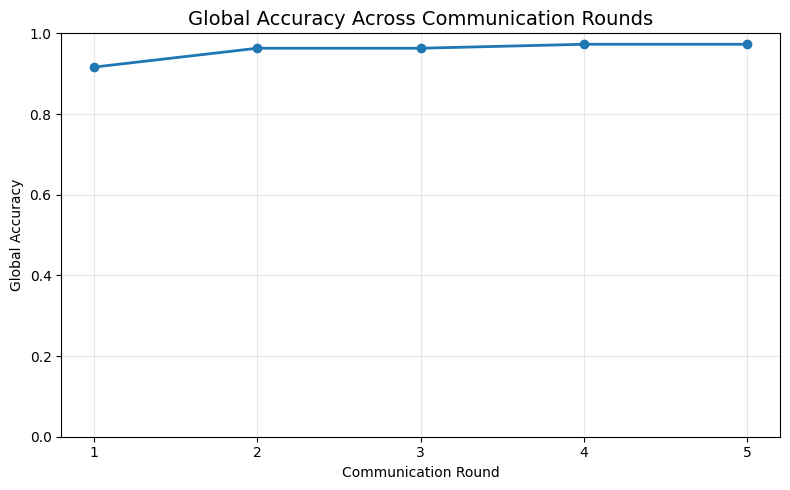

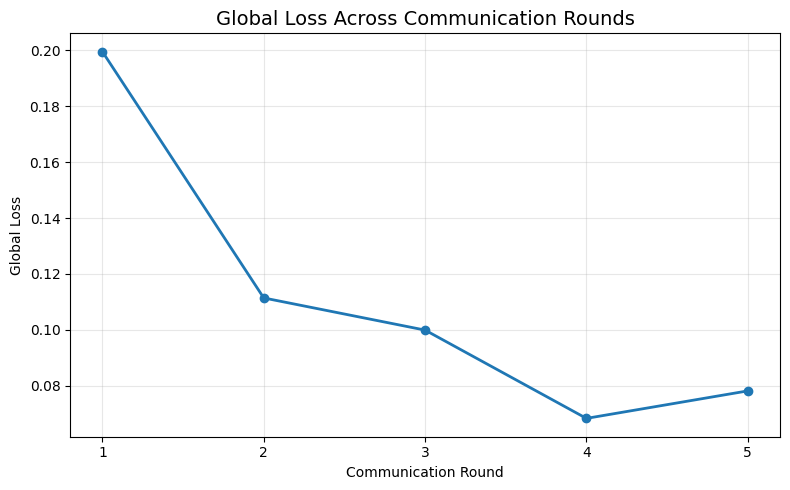

FEDERATED LEARNING ROUND-WISE PERFORMANCE
Round 1: Accuracy = 0.9163 (91.63%), Loss = 0.1996
Round 2: Accuracy = 0.9631 (96.31%), Loss = 0.1114
Round 3: Accuracy = 0.9631 (96.31%), Loss = 0.0999
Round 4: Accuracy = 0.9729 (97.29%), Loss = 0.0683
Round 5: Accuracy = 0.9729 (97.29%), Loss = 0.0781


In [65]:
# ==========================================================
# FEDERATED LEARNING TRAINING PERFORMANCE
# Accuracy & Loss Across Communication Rounds
# ==========================================================

import matplotlib.pyplot as plt

rounds = range(1, COMMUNICATION_ROUNDS + 1)


# ==========================================================
# 1. Global Accuracy
# ==========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    rounds,
    round_accuracy,
    marker="o",
    linewidth=2
)

plt.title(
    "Global Accuracy Across Communication Rounds",
    fontsize=14
)

plt.xlabel("Communication Round")
plt.ylabel("Global Accuracy")

plt.xticks(
    range(1, COMMUNICATION_ROUNDS + 1)
)

plt.ylim(0, 1.0)

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ==========================================================
# 2. Global Loss
# ==========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    rounds,
    round_loss,
    marker="o",
    linewidth=2
)

plt.title(
    "Global Loss Across Communication Rounds",
    fontsize=14
)

plt.xlabel("Communication Round")
plt.ylabel("Global Loss")

plt.xticks(
    range(1, COMMUNICATION_ROUNDS + 1)
)

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ==========================================================
# 3. Round-wise Results
# ==========================================================

print("=" * 65)
print("FEDERATED LEARNING ROUND-WISE PERFORMANCE")
print("=" * 65)

for i in range(COMMUNICATION_ROUNDS):

    print(
        f"Round {i+1}: "
        f"Accuracy = {round_accuracy[i]:.4f} "
        f"({round_accuracy[i] * 100:.2f}%), "
        f"Loss = {round_loss[i]:.4f}"
    )

# ==========================================================
# Evaluation Libraries
# ==========================================================

In [66]:
# ==========================================================
# Evaluation Libraries
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

print("Evaluation Libraries Loaded Successfully")

Evaluation Libraries Loaded Successfully


# ==========================================================
# Predictions
# ==========================================================

In [67]:
# ==========================================================
# Predictions - 4 Class Anxiety Classification
# ==========================================================

# Get probability predictions
y_pred_prob = global_model.predict(
    X_test,
    verbose=0
)

# Convert 4-class probabilities into predicted class
y_pred = np.argmax(
    y_pred_prob,
    axis=1
)

print("Prediction Completed")

print("\nPrediction Shape:")
print("Probability Shape :", y_pred_prob.shape)
print("Class Prediction Shape :", y_pred.shape)

print("\nPredicted Class Distribution:")
print(np.bincount(y_pred, minlength=NUM_CLASSES))

print("\nAnxiety Classes:")
for i, label in enumerate(label_encoder.classes_):
    print(f"{i} → {label}")

Prediction Completed

Prediction Shape:
Probability Shape : (406, 4)
Class Prediction Shape : (406,)

Predicted Class Distribution:
[ 97  39 120 150]

Anxiety Classes:
0 → 0
1 → 1
2 → 2
3 → 3


In [68]:
# ==========================================================
# Evaluation Metrics - 4 Class Anxiety
# ==========================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_pred_prob,
    multi_class="ovr",
    average="weighted"
)


# ==========================================================
# Display Results
# ==========================================================

print("=" * 60)
print("GLOBAL FEDERATED MODEL PERFORMANCE")
print("=" * 60)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC AUC   : {roc_auc:.4f}")

print("\nPercentage Results")
print("-" * 60)

print(f"Accuracy  : {accuracy * 100:.2f}%")
print(f"Precision : {precision * 100:.2f}%")
print(f"Recall    : {recall * 100:.2f}%")
print(f"F1 Score  : {f1 * 100:.2f}%")
print(f"ROC AUC   : {roc_auc * 100:.2f}%")

GLOBAL FEDERATED MODEL PERFORMANCE
Accuracy  : 0.9729
Precision : 0.9757
Recall    : 0.9729
F1 Score  : 0.9734
ROC AUC   : 0.9991

Percentage Results
------------------------------------------------------------
Accuracy  : 97.29%
Precision : 97.57%
Recall    : 97.29%
F1 Score  : 97.34%
ROC AUC   : 99.91%


In [69]:
# ==========================================================
# Classification Report
# ==========================================================

report = classification_report(
    y_test,
    y_pred
)

print(report)

              precision    recall  f1-score   support

           0       0.97      0.93      0.95       101
           1       0.82      1.00      0.90        32
           2       1.00      0.97      0.98       124
           3       0.99      1.00      1.00       149

    accuracy                           0.97       406
   macro avg       0.95      0.97      0.96       406
weighted avg       0.98      0.97      0.97       406



[[ 94   7   0   0]
 [  0  32   0   0]
 [  3   0 120   1]
 [  0   0   0 149]]


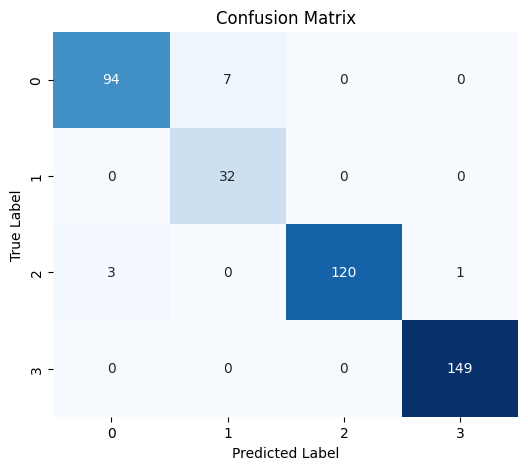

In [70]:
# ==========================================================
# Confusion Matrix Heatmap
# ==========================================================
# ==========================================================
# Confusion Matrix
# ==========================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    fmt="d",
    cbar=False
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.show()

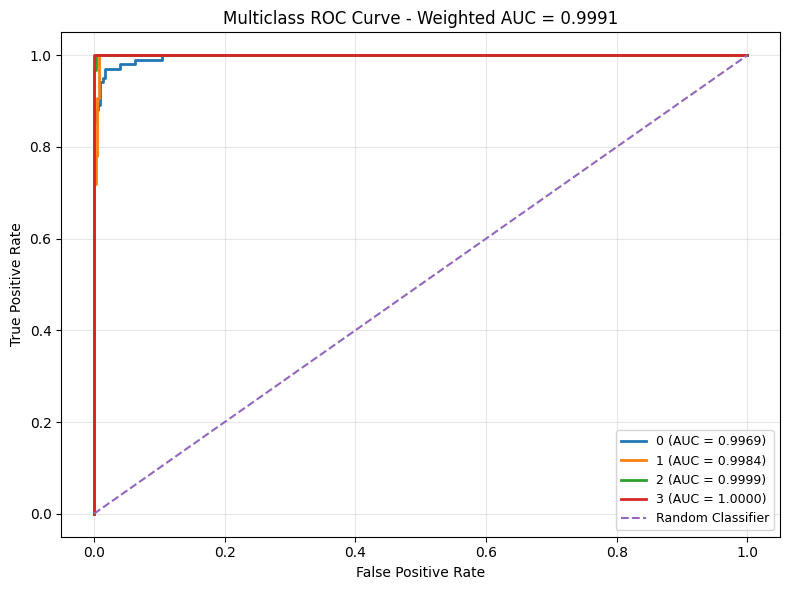

MULTICLASS ROC-AUC
Weighted ROC-AUC: 0.9991


In [72]:
# ==========================================================
# Multiclass ROC Curve - 4 Anxiety Classes
# ==========================================================

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# Convert true labels to one-hot/binary format
y_test_bin = label_binarize(
    y_test,
    classes=np.arange(NUM_CLASSES)
)

# Calculate ROC-AUC
roc_auc = roc_auc_score(
    y_test_bin,
    y_pred_prob,
    multi_class="ovr",
    average="weighted"
)

plt.figure(figsize=(8, 6))

# Plot ROC for each anxiety class
for i in range(NUM_CLASSES):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_pred_prob[:, i]
    )

    class_auc = roc_auc_score(
        y_test_bin[:, i],
        y_pred_prob[:, i]
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{label_encoder.classes_[i]} (AUC = {class_auc:.4f})"
    )

# Random classifier line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    f"Multiclass ROC Curve - Weighted AUC = {roc_auc:.4f}"
)

plt.legend(
    loc="lower right",
    fontsize=9
)

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("=" * 60)
print("MULTICLASS ROC-AUC")
print("=" * 60)
print(f"Weighted ROC-AUC: {roc_auc:.4f}")

# ==========================================================
# Performance Comparison
# ==========================================================

FEDERATED LEARNING PERFORMANCE
Accuracy    : 0.9729 (97.29%)
Precision   : 0.9757 (97.57%)
Recall      : 0.9729 (97.29%)
F1 Score    : 0.9734 (97.34%)
ROC-AUC     : 0.9991 (99.91%)


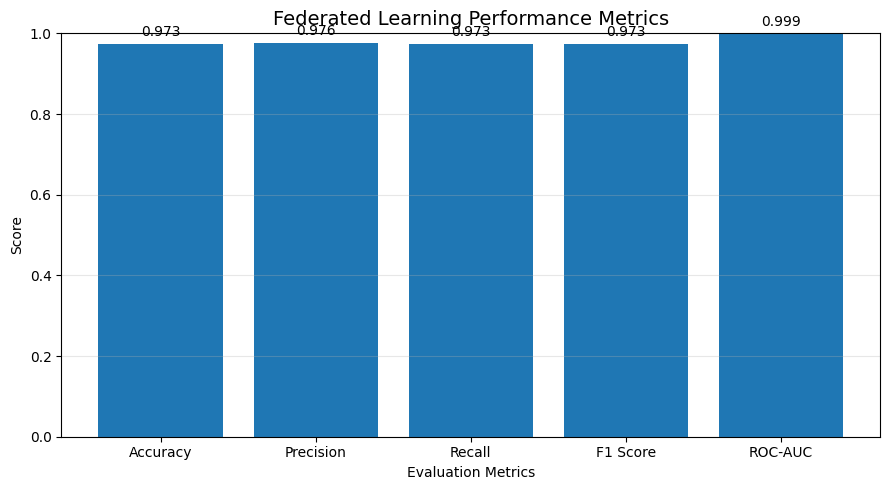

In [73]:
# ==========================================================
# Performance Comparison - 4 Class Anxiety
# ==========================================================

# Calculate Metrics
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

# Multiclass ROC-AUC
roc_auc = roc_auc_score(
    y_test,
    y_pred_prob,
    multi_class="ovr",
    average="weighted"
)


# ==========================================================
# Store Metrics
# ==========================================================

metrics = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "ROC-AUC": roc_auc
}


# ==========================================================
# Print Results
# ==========================================================

print("=" * 60)
print("FEDERATED LEARNING PERFORMANCE")
print("=" * 60)

for name, value in metrics.items():
    print(f"{name:<12}: {value:.4f} ({value*100:.2f}%)")


# ==========================================================
# Performance Graph
# ==========================================================

plt.figure(figsize=(9, 5))

bars = plt.bar(
    metrics.keys(),
    metrics.values()
)

plt.ylim(0, 1.0)

plt.title(
    "Federated Learning Performance Metrics",
    fontsize=14
)

plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")

plt.grid(
    axis="y",
    alpha=0.3
)

# Add values above bars
for bar, value in zip(bars, metrics.values()):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.3f}",
        ha="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

In [74]:
# ==========================================================
# Prediction Results - 4 Class Anxiety
# ==========================================================

results = pd.DataFrame({

    "Actual": label_encoder.inverse_transform(y_test),

    "Predicted": label_encoder.inverse_transform(y_pred),

    "Actual_Code": y_test,

    "Predicted_Code": y_pred,

    "Minimal_Prob": y_pred_prob[:, 0],

    "Mild_Prob": y_pred_prob[:, 1],

    "Moderate_Prob": y_pred_prob[:, 2],

    "Severe_Prob": y_pred_prob[:, 3]

})

# Round probability values
prob_columns = [
    "Minimal_Prob",
    "Mild_Prob",
    "Moderate_Prob",
    "Severe_Prob"
]

results[prob_columns] = results[prob_columns].round(4)

print("=" * 80)
print("PREDICTION RESULTS")
print("=" * 80)

display(results.head(10))

PREDICTION RESULTS


,Actual,Predicted,Actual_Code,Predicted_Code,Minimal_Prob,Mild_Prob,Moderate_Prob,Severe_Prob
0,2,2,2,2,0.1055,0.0000,0.8945,0.0000
1,3,3,3,3,0.0000,0.0000,0.0165,0.9835
2,2,2,2,2,0.0000,0.0000,0.9833,0.0167
3,3,3,3,3,0.0000,0.0000,0.0000,1.0000
4,2,2,2,2,0.0002,0.0000,0.9998,0.0000
5,2,2,2,2,0.4545,0.0000,0.5455,0.0000
6,2,2,2,2,0.0000,0.0000,0.9999,0.0001
7,1,1,1,1,0.0168,0.9832,0.0000,0.0000
8,3,3,3,3,0.0000,0.0000,0.0000,1.0000
9,0,0,0,0,0.5174,0.4826,0.0000,0.0000


# Notebook 3

# ==========================================================
##  Install Explainable AI Libraries
# ==========================================================

In [75]:
# ==========================================================
# Install Explainable AI Libraries
# ==========================================================

!pip -q install shap lime

In [76]:
# ==========================================================
# Import Required Libraries
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import shap

from lime.lime_tabular import LimeTabularExplainer

from tensorflow.keras.models import load_model

print("Libraries Imported Successfully")

Libraries Imported Successfully


# ==========================================================
##  Save Final Federated Model
# ==========================================================

In [77]:
# ==========================================================
# Save Final Federated Model
# ==========================================================

MODEL_PATH = "/kaggle/working/federated_anxiety_model.keras"

global_model.save(MODEL_PATH)

print("="*60)
print("Federated Model Saved Successfully")
print(MODEL_PATH)
print("="*60)

Federated Model Saved Successfully
/kaggle/working/federated_anxiety_model.keras


In [78]:
# ==========================================================
# Load Saved Federated Model
# ==========================================================

federated_model = load_model(MODEL_PATH)

print("="*60)
print("Federated Model Loaded Successfully")
print("="*60)

federated_model.summary()

Federated Model Loaded Successfully


Model: "sequential_81"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_324 (Dense)               │ (None, 128)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_162 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_325 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_163 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_326 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_327 (Dense)               │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,550 (146.68 KB)

 Trainable params: 12,516 (48.89 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 25,034 (97.79 KB)

# ==========================================================
##  Dataset Information
# ==========================================================

In [79]:
# ==========================================================
# Dataset Information
# ==========================================================

print("="*60)
print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)
print("Total Features :", X_train.shape[1])
print("="*60)

feature_names = list(X.columns)

print("\nFeature Names")

for i, feature in enumerate(feature_names, start=1):
    print(f"{i}. {feature}")

Training Shape : (1622, 15)
Testing Shape  : (406, 15)
Total Features : 15

Feature Names
1. Age
2. Gender
3. University
4. Department
5. Academic Year
6. Current CGPA
7. Did you receive a waiver or scholarship at your university?
8. 1. In a semester, how often you felt nervous, anxious or on edge due to academic pressure? 
9. 2. In a semester, how often have you been unable to stop worrying about your academic affairs? 
10. 3. In a semester, how often have you had trouble relaxing due to academic pressure? 
11. 4. In a semester, how often have you been easily annoyed or irritated because of academic pressure?
12. 5. In a semester, how often have you worried too much about academic affairs? 
13. 6. In a semester, how often have you been so restless due to academic pressure that it is hard to sit still?
14. 7. In a semester, how often have you felt afraid, as if something awful might happen?
15. Anxiety Value


# ==========================================================
##  Predict Using Loaded Model
# ==========================================================

In [80]:
# ==========================================================
# Predict Using Loaded Model
# ==========================================================

pred_prob = federated_model.predict(X_test, verbose=0)

pred_class = (pred_prob >= 0.5).astype(int)

pred_prob = pred_prob.flatten()
pred_class = pred_class.flatten()

print("="*60)
print("Prediction Completed Successfully")
print("="*60)

print("Total Predictions :", len(pred_class))

Prediction Completed Successfully
Total Predictions : 1624


# ==========================================================
##  Create Explainability Dataset
# ==========================================================

In [82]:
# ==========================================================
# Create Explainability Dataset - 4 Class Anxiety
# ==========================================================

# Get encoded feature names
feature_names = preprocessor.get_feature_names_out()

# Create Explainability DataFrame
explain_df = pd.DataFrame(
    X_test,
    columns=feature_names
)

# Actual and predicted class names
explain_df["Actual"] = label_encoder.inverse_transform(
    y_test
)

explain_df["Predicted"] = label_encoder.inverse_transform(
    y_pred
)

# Maximum prediction confidence
explain_df["Prediction_Confidence"] = np.max(
    y_pred_prob,
    axis=1
)

# Add individual class probabilities
explain_df["Minimal_Probability"] = y_pred_prob[:, 0]

explain_df["Mild_Probability"] = y_pred_prob[:, 1]

explain_df["Moderate_Probability"] = y_pred_prob[:, 2]

explain_df["Severe_Probability"] = y_pred_prob[:, 3]


print("=" * 70)
print("EXPLAINABILITY DATASET")
print("=" * 70)

print("Shape:", explain_df.shape)

display(explain_df.head())

EXPLAINABILITY DATASET
Shape: (406, 22)


,num__Age,num__Gender,num__University,num__Department,num__Academic Year,num__Current CGPA,num__Did you receive a waiver or scholarship at your university?,"num__1. In a semester, how often you felt nervous, anxious or on edge due to academic pressure?","num__2. In a semester, how often have you been unable to stop worrying about your academic affairs?","num__3. In a semester, how often have you had trouble relaxing due to academic pressure?",...,"num__6. In a semester, how often have you been so restless due to academic pressure that it is hard to sit still?","num__7. In a semester, how often have you felt afraid, as if something awful might happen?",num__Anxiety Value,Actual,Predicted,Prediction_Confidence,Minimal_Probability,Mild_Probability,Moderate_Probability,Severe_Probability
0,-0.699500,0.642219,0.843835,-0.285963,-1.176583,2.217753,-0.521687,-0.833947,-0.633498,-0.757888,...,0.206214,0.255648,-0.431120,2,2,0.894493,1.055014e-01,1.345273e-06,8.944930e-01,0.000004
1,-0.699500,0.642219,-1.502061,-0.285963,1.255297,-0.545070,-0.521687,0.225303,0.342318,1.247486,...,1.213681,0.255648,0.482489,3,3,0.983484,3.733820e-10,2.095818e-14,1.651624e-02,0.983484
2,1.124598,0.642219,-1.502061,-0.285963,-0.568613,-0.545070,-0.521687,0.225303,0.342318,0.244799,...,0.206214,0.255648,0.299767,2,2,0.983262,4.146421e-06,1.025105e-10,9.832624e-01,0.016734
3,-0.699500,-1.479326,0.583180,-0.285963,0.647327,0.836342,1.916860,1.284553,1.318133,1.247486,...,1.213681,1.202363,1.578819,3,3,1.000000,3.944475e-27,6.550286e-30,2.866226e-14,1.000000
4,-0.699500,0.642219,0.843835,1.268781,-1.176583,2.217753,1.916860,0.225303,0.342318,0.244799,...,-0.801253,-0.691067,-0.248398,2,2,0.999791,1.693758e-04,9.137271e-10,9.997909e-01,0.000040


# ==========================================================
##  Prediction Distribution
# ==========================================================

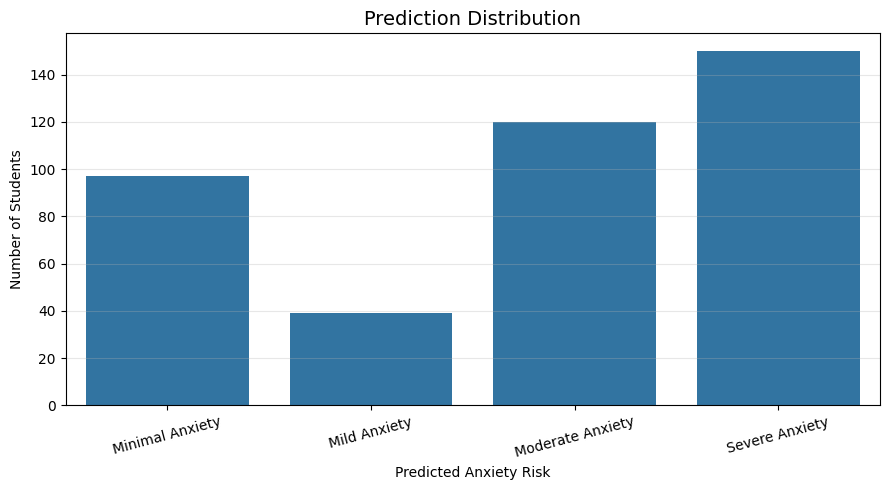

In [83]:
# ==========================================================
# Prediction Distribution - 4 Class Anxiety
# ==========================================================

plt.figure(figsize=(9, 5))

sns.countplot(
    x=y_pred
)

plt.title(
    "Prediction Distribution",
    fontsize=14
)

plt.xlabel("Predicted Anxiety Risk")
plt.ylabel("Number of Students")

# Correct 4-class labels
plt.xticks(
    ticks=[0, 1, 2, 3],
    labels=[
        "Minimal Anxiety",
        "Mild Anxiety",
        "Moderate Anxiety",
        "Severe Anxiety"
    ],
    rotation=15
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

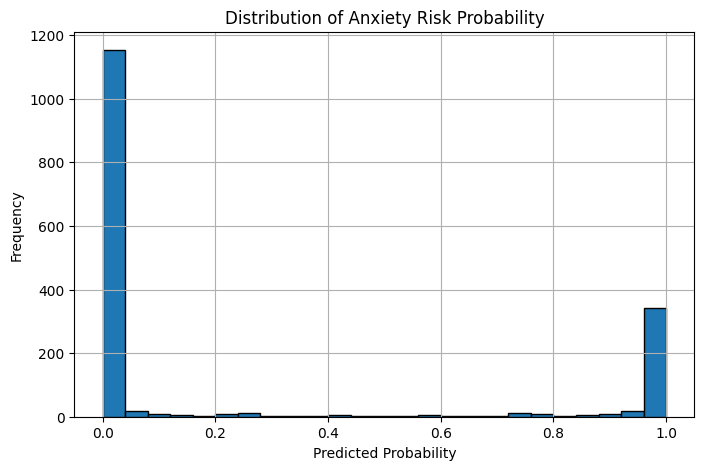

In [84]:
# ==========================================================
# Prediction Probability Distribution
# ==========================================================

plt.figure(figsize=(8,5))

plt.hist(
    pred_prob,
    bins=25,
    edgecolor="black"
)

plt.xlabel("Predicted Probability")

plt.ylabel("Frequency")

plt.title("Distribution of Anxiety Risk Probability")

plt.grid(True)

plt.show()

# (SHAP Explainable AI)

In [85]:
# ==========================================================
# SHAP Background Dataset
# ==========================================================

# Use a subset of training data for faster SHAP computation
background_data = X_train[:100]

print("="*60)
print("Background Dataset Shape")
print(background_data.shape)
print("="*60)

Background Dataset Shape
(100, 15)


In [86]:
# ==========================================================
# Prediction Function
# ==========================================================

def model_predict(data):
    data = np.array(data).astype(np.float32)
    return federated_model.predict(data, verbose=0)


# ==========================================================
# Initialize SHAP Explainer
# ==========================================================

print("="*60)
print("Initializing SHAP Explainer...")
print("="*60)

explainer = shap.KernelExplainer(
    model_predict,
    background_data
)

print("SHAP Explainer Ready")
# ==========================================================
# Calculate SHAP Values
# ==========================================================

# Explain first 20 test samples (fast and sufficient for thesis)
sample_size = 20

sample_data = X_test[:sample_size]

print("="*60)
print("Calculating SHAP Values...")
print("="*60)

shap_values = explainer.shap_values(
    sample_data,
    nsamples=100
)

print("SHAP Calculation Completed")

Initializing SHAP Explainer...
SHAP Explainer Ready
Calculating SHAP Values...


  0%|          | 0/20 [00:00<?, ?it/s]

SHAP Calculation Completed


In [87]:
print(type(shap_values))

if isinstance(shap_values, list):
    print("LIST")
    print(np.array(shap_values[0]).shape)
else:
    print("ARRAY")
    print(np.array(shap_values).shape)

<class 'numpy.ndarray'>
ARRAY
(20, 15, 4)


In [88]:
# ==========================================================
# Fix SHAP Dimensions
# ==========================================================

sv = np.array(shap_values)

print("Original Shape :", sv.shape)

# Remove last singleton dimension if present
if sv.ndim == 3:
    sv = sv[:,:,0]

print("Updated Shape :", sv.shape)

Original Shape : (20, 15, 4)
Updated Shape : (20, 15)


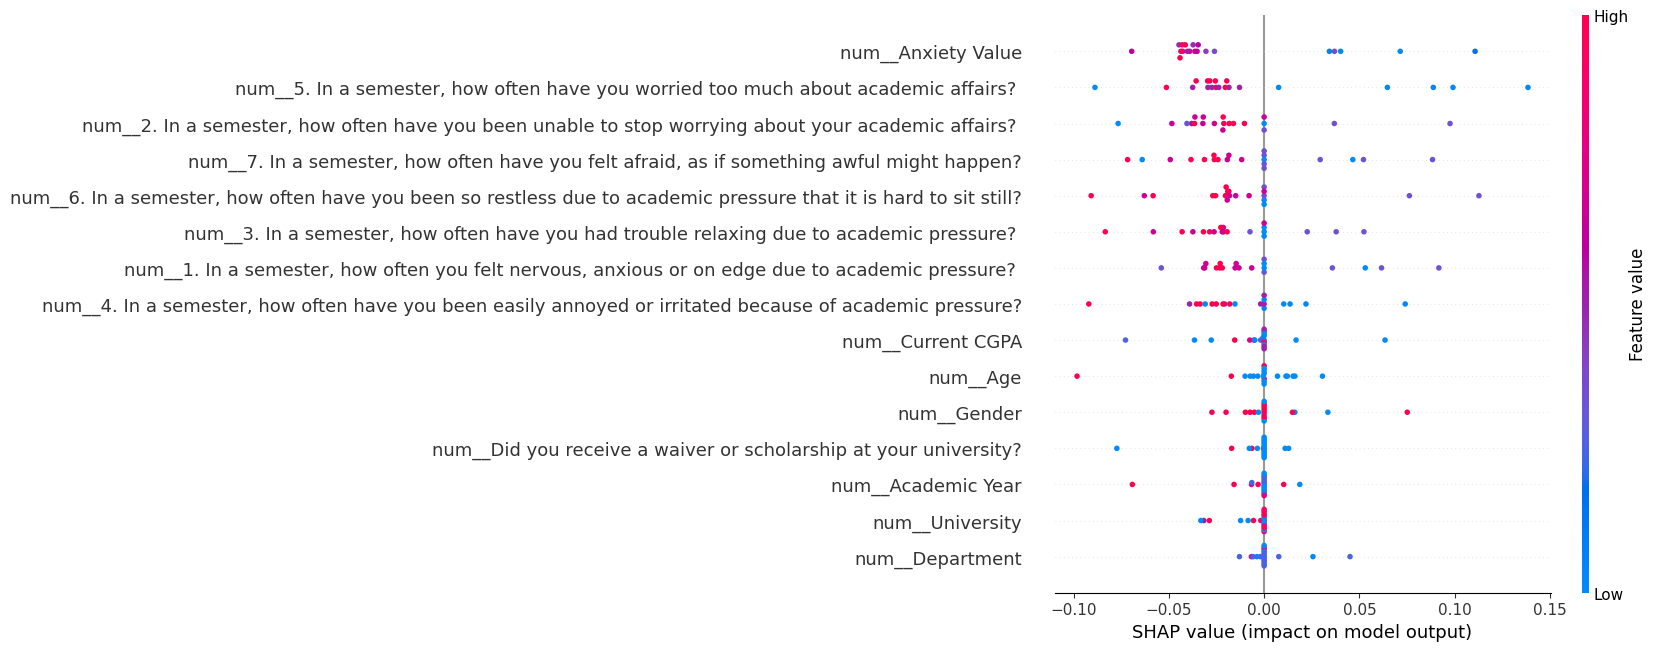

In [89]:
# ==========================================================
# SHAP Summary Plot
# ==========================================================

shap.summary_plot(
    sv,
    sample_data,
    feature_names=feature_names
)

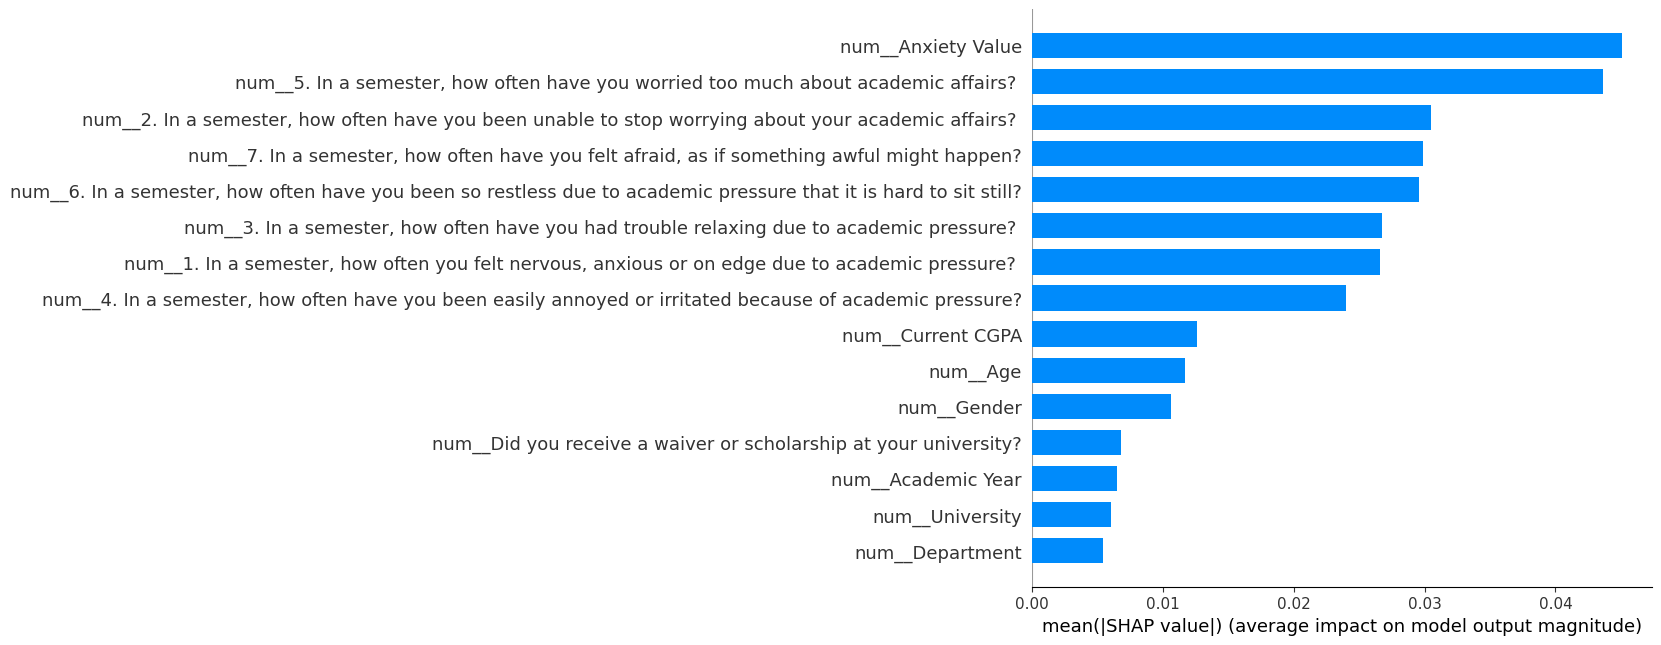

In [90]:
# ==========================================================
# SHAP Bar Plot
# ==========================================================

shap.summary_plot(
    sv,
    sample_data,
    feature_names=feature_names,
    plot_type="bar"
)

In [91]:
# ==========================================================
# Mean Absolute SHAP Values
# ==========================================================

importance = np.mean(np.abs(sv), axis=0)

importance_df = pd.DataFrame({

    "Feature":feature_names,

    "Importance":importance

})

importance_df = importance_df.sort_values(

    "Importance",

    ascending=False

)

importance_df.reset_index(drop=True,inplace=True)

importance_df

,Feature,Importance
0,num__Anxiety Value,0.045084
1,"num__5. In a semester, how often have you worr...",0.043641
2,"num__2. In a semester, how often have you been...",0.030494
3,"num__7. In a semester, how often have you felt...",0.029861
4,"num__6. In a semester, how often have you been...",0.029570
5,"num__3. In a semester, how often have you had ...",0.026783
6,"num__1. In a semester, how often you felt nerv...",0.026623
7,"num__4. In a semester, how often have you been...",0.024037
8,num__Current CGPA,0.012647
9,num__Age,0.011727


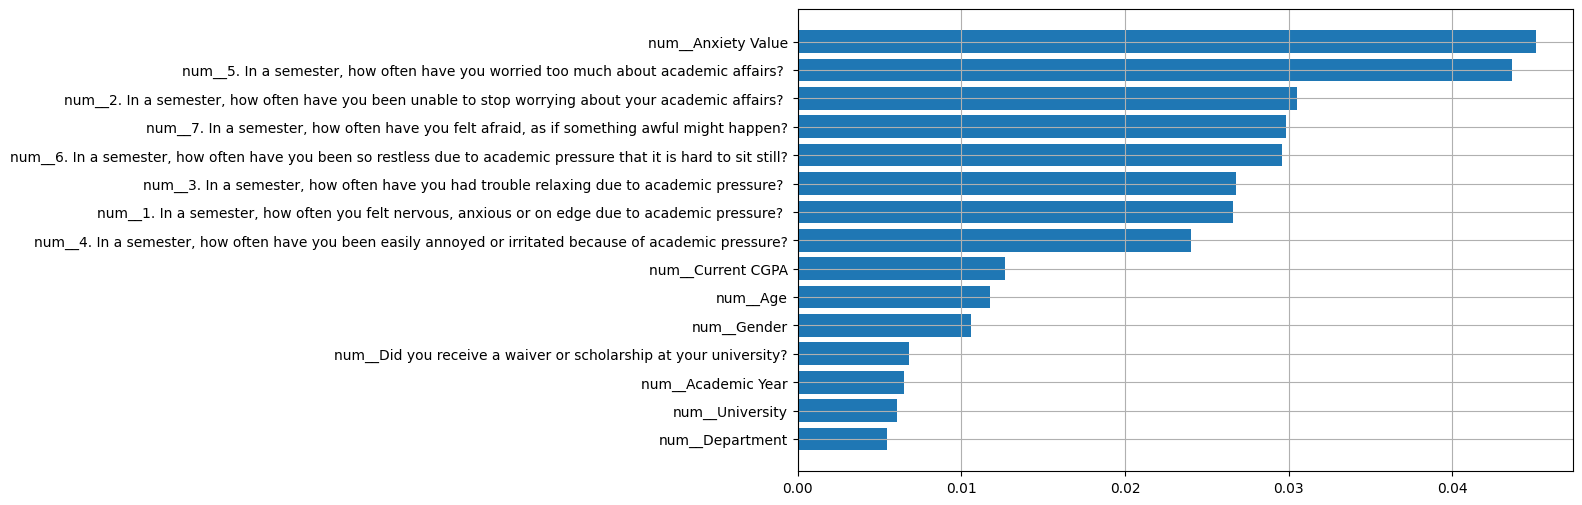

In [92]:
# ==========================================================
# Importance Graph
# ==========================================================

plt.figure(figsize=(10,6))

plt.barh(

    importance_df["Feature"],

    importance_df["Importance"]

)

plt.gca().invert_yaxis()

plt.grid()

plt.show()

In [93]:
importance_df.to_csv(

"/kaggle/working/shap_feature_importance.csv",

index=False

)

print("Saved Successfully")

Saved Successfully


# LIME Explainer

In [94]:
# ==========================================================
# Create LIME Explainer
# ==========================================================

from lime.lime_tabular import LimeTabularExplainer

lime_explainer = LimeTabularExplainer(

    training_data=X_train,

    feature_names=feature_names,

    class_names=["Low Anxiety","High Anxiety"],

    mode="classification",

    discretize_continuous=True,

    random_state=42

)

print("="*60)
print("LIME Explainer Created Successfully")
print("="*60)

LIME Explainer Created Successfully


In [95]:
# ==========================================================
# Prediction Function for LIME
# ==========================================================

def lime_predict(data):

    data = np.array(data).astype(np.float32)

    prob1 = federated_model.predict(data, verbose=0)

    prob0 = 1 - prob1

    return np.concatenate([prob0, prob1], axis=1)

In [96]:
# ==========================================================
# Test Prediction Function
# ==========================================================

pred = lime_predict(X_test[:5])

print(pred)

print(pred.shape)

# ==========================================================
# Explain First Student
# ==========================================================

student_id = 0

lime_exp = lime_explainer.explain_instance(

    data_row=X_test[student_id],

    predict_fn=lime_predict,

    num_features=10,

    top_labels=1

)

print("="*60)
print("LIME Explanation Generated")
print("="*60)

[[8.94498646e-01 9.99998629e-01 1.05507016e-01 9.99995768e-01
  1.05501361e-01 1.34527306e-06 8.94492984e-01 4.23512665e-06]
 [1.00000000e+00 1.00000000e+00 9.83483791e-01 1.65162683e-02
  3.73382048e-10 2.09581769e-14 1.65162366e-02 9.83483732e-01]
 [9.99995828e-01 1.00000000e+00 1.67376995e-02 9.83266413e-01
  4.14642091e-06 1.02510486e-10 9.83262300e-01 1.67335924e-02]
 [1.00000000e+00 1.00000000e+00 1.00000000e+00 0.00000000e+00
  3.94447555e-27 6.55028710e-30 2.86622600e-14 1.00000000e+00]
 [9.99830604e-01 1.00000000e+00 2.09152699e-04 9.99960244e-01
  1.69375751e-04 9.13727038e-10 9.99790847e-01 3.97726071e-05]]
(5, 8)
LIME Explanation Generated


In [97]:
# ==========================================================
# Feature Contributions
# ==========================================================

lime_exp.as_list()

[('num__4. In a semester, how often have you been easily annoyed or irritated because of academic pressure? <= -0.81',
  -0.010915779275469634),
 ('num__2. In a semester, how often have you been unable to stop worrying about your academic affairs?  <= -0.63',
  -0.00869574826197589),
 ('num__3. In a semester, how often have you had trouble relaxing due to academic pressure?  <= -0.76',
  -0.008620573738596744),
 ('num__1. In a semester, how often you felt nervous, anxious or on edge due to academic pressure?  <= -0.83',
  -0.008041145614583432),
 ('-0.88 < num__5. In a semester, how often have you worried too much about academic affairs?  <= 0.14',
  0.004940580550777782),
 ('-0.80 < num__6. In a semester, how often have you been so restless due to academic pressure that it is hard to sit still? <= 0.21',
  0.004854221528007289),
 ('-0.69 < num__7. In a semester, how often have you felt afraid, as if something awful might happen? <= 0.26',
  0.0033911505566568754),
 ('num__Did you rece

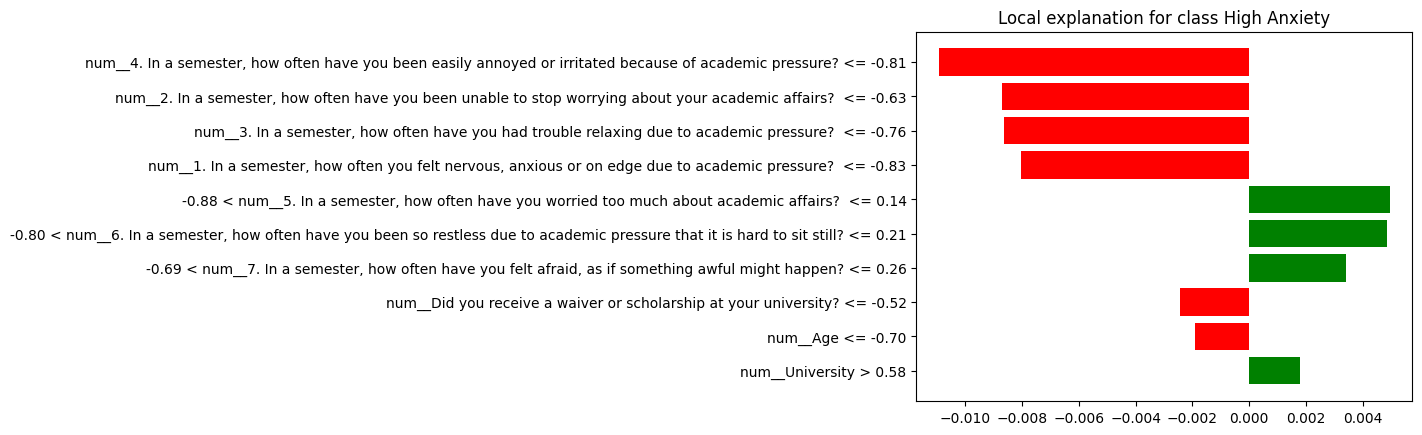

Student Index : 15
Probability : 0.99999994


[('0.14 < num__5. In a semester, how often have you worried too much about academic affairs?  <= 1.16',
  0.006851146996575358),
 ('-0.83 < num__1. In a semester, how often you felt nervous, anxious or on edge due to academic pressure?  <= 0.23',
  0.005384016572307077),
 ('0.23 < num__4. In a semester, how often have you been easily annoyed or irritated because of academic pressure? <= 1.27',
  0.005330940011215935),
 ('0.12 < num__Anxiety Value <= 0.85', 0.005204327824489771),
 ('-0.63 < num__2. In a semester, how often have you been unable to stop worrying about your academic affairs?  <= 0.34',
  0.004877278975455468),
 ('-0.76 < num__3. In a semester, how often have you had trouble relaxing due to academic pressure?  <= 0.24',
  0.0038695674039475056),
 ('-0.69 < num__7. In a semester, how often have you felt afraid, as if something awful might happen? <= 0.26',
  0.003482899250703516),
 ('num__University > 0.58', 0.00320075398635053),
 ('num__Did you receive a waiver or scholarsh

In [98]:
# ==========================================================
# LIME Plot
# ==========================================================

fig = lime_exp.as_pyplot_figure()

plt.tight_layout()

plt.show()
# ==========================================================
# Find High Anxiety Prediction
# ==========================================================

high_index = np.argmax(pred_prob)

print("Student Index :", high_index)

print("Probability :", pred_prob[high_index])

# ==========================================================
# High Anxiety Explanation
# ==========================================================

high_exp = lime_explainer.explain_instance(

    X_test[high_index],

    lime_predict,

    num_features=10,

    top_labels=1

)

high_exp.as_list()

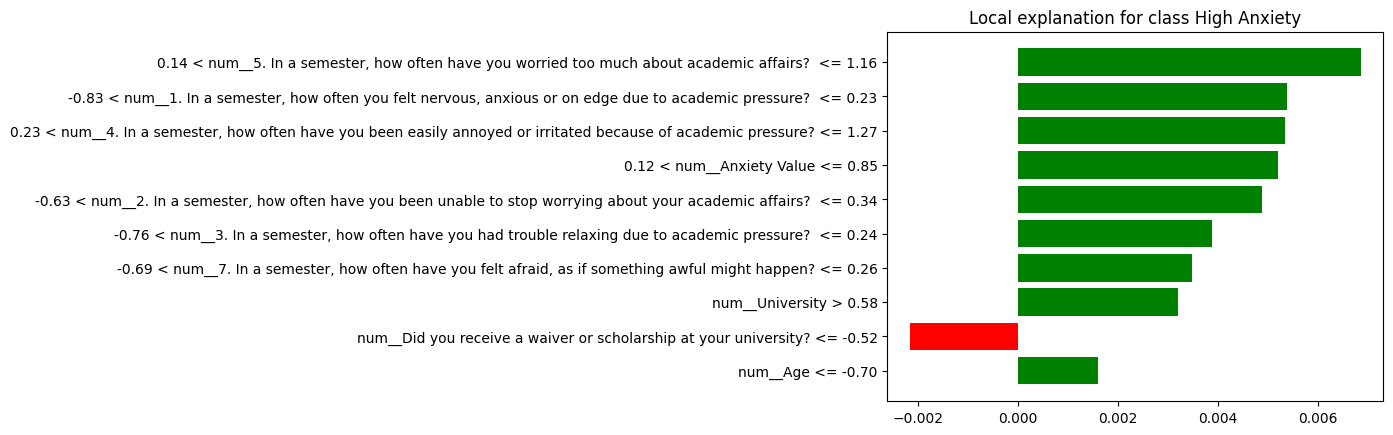

Low Anxity predictions
229
2.9253475e-31


In [99]:
# ==========================================================
# Plot High Anxiety Explanation
# ==========================================================

fig = high_exp.as_pyplot_figure()

plt.tight_layout()

plt.show()
# ==========================================================
# Find Lowest Anxiety Prediction
# ==========================================================
print("Low Anxity predictions")
low_index = np.argmin(pred_prob)

print(low_index)

print(pred_prob[low_index])


In [100]:
# ==========================================================
# Low Anxiety Explanation (Fixed)
# ==========================================================

low_exp = lime_explainer.explain_instance(

    data_row=X_test[low_index],

    predict_fn=lime_predict,

    num_features=10,

    labels=(0,)      # Explain Low Anxiety class

)

print("="*60)
print("Low Anxiety Explanation Generated")
print("="*60)

low_features = low_exp.as_list(label=0)

low_features

Low Anxiety Explanation Generated


[('num__Anxiety Value > 0.85', 0.15078949664708657),
 ('0.26 < num__7. In a semester, how often have you felt afraid, as if something awful might happen? <= 1.20',
  0.14718873454856712),
 ('0.24 < num__3. In a semester, how often have you had trouble relaxing due to academic pressure?  <= 1.25',
  0.14643582399572944),
 ('0.14 < num__5. In a semester, how often have you worried too much about academic affairs?  <= 1.16',
  0.13934348863542786),
 ('0.23 < num__1. In a semester, how often you felt nervous, anxious or on edge due to academic pressure?  <= 1.28',
  0.13732806534624714),
 ('0.21 < num__6. In a semester, how often have you been so restless due to academic pressure that it is hard to sit still? <= 1.21',
  0.13678374283540573),
 ('0.34 < num__2. In a semester, how often have you been unable to stop worrying about your academic affairs?  <= 1.32',
  0.12854177740529932),
 ('0.23 < num__4. In a semester, how often have you been easily annoyed or irritated because of academic p

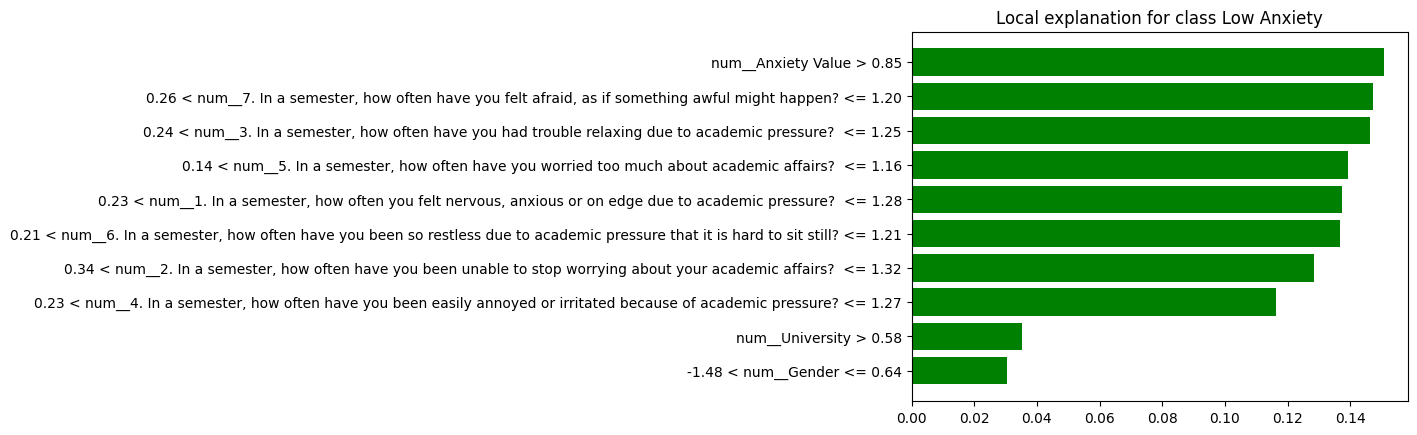

In [101]:
# ==========================================================
# Plot Low Anxiety Explanation
# ==========================================================

fig = low_exp.as_pyplot_figure(label=0)

plt.tight_layout()

plt.show()

In [102]:
# ==========================================================
# Save LIME Explanation
# ==========================================================

lime_results = pd.DataFrame(

    low_features,

    columns=["Feature", "Contribution"]

)

lime_results.to_csv(

    "/kaggle/working/lime_low_anxiety.csv",

    index=False

)

print("="*60)
print("LIME Results Saved Successfully")
print("="*60)

lime_results.head()

LIME Results Saved Successfully


,Feature,Contribution
0,num__Anxiety Value > 0.85,0.150789
1,"0.26 < num__7. In a semester, how often have y...",0.147189
2,"0.24 < num__3. In a semester, how often have y...",0.146436
3,"0.14 < num__5. In a semester, how often have y...",0.139343
4,"0.23 < num__1. In a semester, how often you fe...",0.137328
